<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/leon/Asah_Fetch_A25_CS328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [91]:
# Library Essential
import numpy as np
import pandas as pd
import os
import shutil
from google.colab import files
from datetime import datetime

# Library Pre-processing Data
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Library Machine Learning
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Library Visualisasi Data
import plotly as py
import plotly.graph_objs as go
import seaborn as sns
import matplotlib.pyplot as plt


# **Load Dataset**

Load dataset yang dari Kaggle:
- Online Retail Dataset (UCI)
- Online Retail Dataset II (UCI)

In [2]:
# Upload file .json untuk API key
files.upload()
print("API Key Received")

Saving kaggle.json to kaggle.json
API Key Received


In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Download dataset dari Kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d viridianachow/online-retail-uci-dataset
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/viridianachow/online-retail-uci-dataset
License(s): unknown
  0% 0.00/7.15M [00:00<?, ?B/s]
100% 7.15M/7.15M [00:00<00:00, 708MB/s]
Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
  0% 0.00/14.5M [00:00<?, ?B/s]
100% 14.5M/14.5M [00:00<00:00, 1.05GB/s]


In [4]:
!unzip "online-retail-uci-dataset.zip"
!unzip "online-retail-ii-uci.zip"

Archive:  online-retail-uci-dataset.zip
  inflating: Online Retail.csv       
Archive:  online-retail-ii-uci.zip
  inflating: online_retail_II.csv    


In [5]:
# Simpan dataset dari csv ke DataFrame Pandas
df_1 = pd.read_csv('Online Retail.csv')
df_2 = pd.read_csv('online_retail_II.csv')

In [6]:
df_1.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom


In [7]:
df_2.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) untuk mencari dari pola data pembelian

In [8]:
# Menyamakan nama kolom agar kedua DataFrame dapat digabung
column_names = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
df_1.columns = df_2.columns = column_names

In [9]:
# Gabung menjadi 1 DataFrame
df_all = pd.concat([df_1, df_2])
df_all.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Informasi Dataset

In [10]:
# Tampilkan info dataset
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


In [11]:
df_all.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
count,1609280,1609280,1603444,1.609280e+06,1609280,1.609280e+06,1.231193e+06,1609280
unique,53628,5305,5698,NaN,70895,NaN,NaN,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,2228,8142,8287,NaN,1350,NaN,NaN,1476808
mean,NaN,NaN,NaN,9.808698e+00,NaN,4.636499e+00,1.531243e+04,NaN
std,NaN,NaN,NaN,1.892047e+02,NaN,1.152285e+02,1.702901e+03,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,1.234600e+04,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,1.396900e+04,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,1.522000e+04,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.130000e+00,1.679500e+04,NaN


### Korelasi Antar Variabel

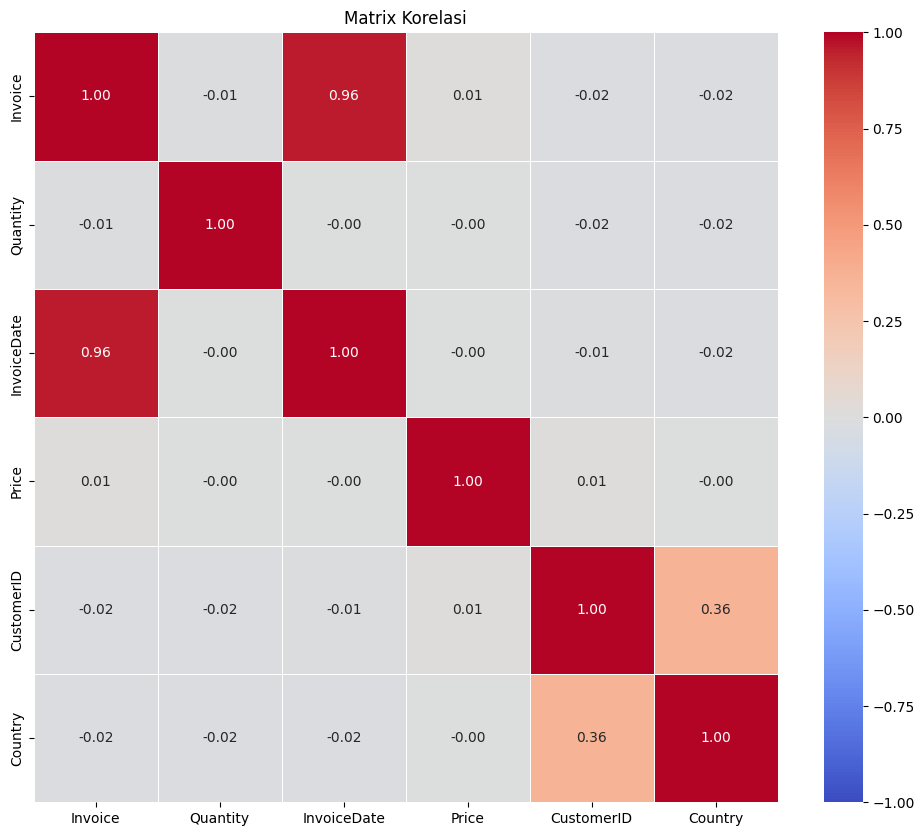

In [12]:
# Encode variabel kategorikal yang relevan
label_encoder = LabelEncoder()
df_lencoder = df_all.drop(['StockCode', 'Description'], axis=1)

# Konversi tanggal ke format yang sesuai
df_lencoder['InvoiceDate'] = pd.to_datetime(df_lencoder['InvoiceDate'], format='mixed')
category_features = ['Invoice', 'CustomerID', 'Country']
for col in category_features:
  df_lencoder[col] = label_encoder.fit_transform(df_all[col])

plt.figure(figsize=(12, 10))
matrix_korelasi = df_lencoder.corr()

sns.heatmap(matrix_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrix Korelasi')
plt.show()

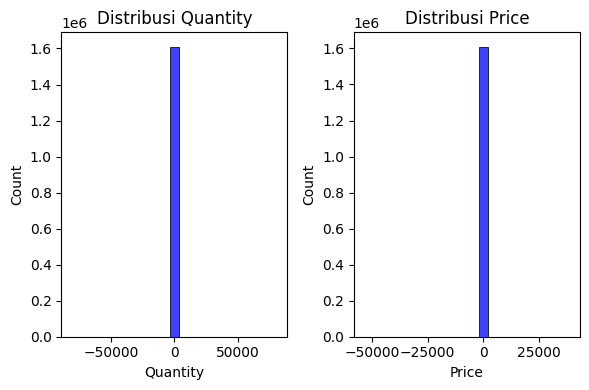

In [37]:
column_display = ['Quantity', 'Price']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column_display, 1):
  plt.subplot(1, 2, i)
  sns.histplot(df_all[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

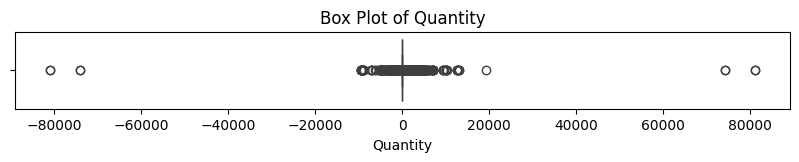

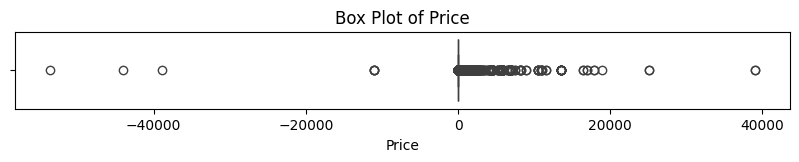

In [14]:
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_all[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

# **Data Cleaning & Preprocessing**

### Data Cleaning

##### Hapus missing values dan data duplikat

In [15]:
print("Data duplikat:", df_all.duplicated().sum())

print("Data hilang: ")
missing_values = df_all.isnull().sum()
missing_values[missing_values > 0]

Data duplikat: 39603
Data hilang: 


,0
Description,5836
CustomerID,378087


In [16]:
# Hapus data duplikat
df_clean = df_all.drop_duplicates()

# Hapus data hilang
filter_custID = (df_clean['CustomerID'].notnull() & df_clean['Description'].notnull())
df_clean = df_clean[filter_custID]

In [17]:
# Cek informasi dataset setelah cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199489 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1199489 non-null  object 
 1   StockCode    1199489 non-null  object 
 2   Description  1199489 non-null  object 
 3   Quantity     1199489 non-null  int64  
 4   InvoiceDate  1199489 non-null  object 
 5   Price        1199489 non-null  float64
 6   CustomerID   1199489 non-null  float64
 7   Country      1199489 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 82.4+ MB


##### Hapus data negatif

In [18]:
# Buat & apply filter untuk data negatif
filter_price = df_clean['Price'] >= 0
df_clean = df_clean[filter_price]
filter_quantity = df_clean['Quantity'] >= 0
df_clean = df_clean[filter_quantity]

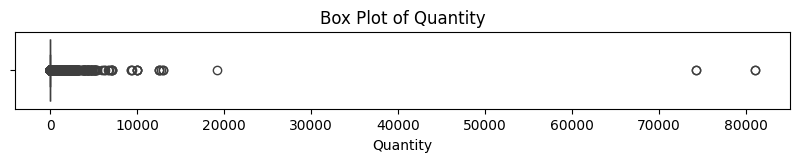

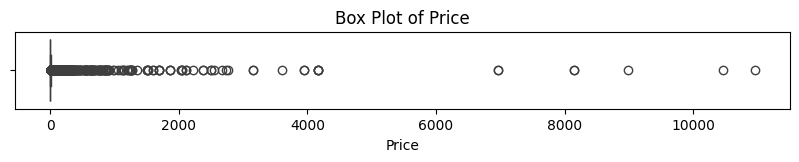

In [19]:
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_clean[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

In [20]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172227 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1172227 non-null  object 
 1   StockCode    1172227 non-null  object 
 2   Description  1172227 non-null  object 
 3   Quantity     1172227 non-null  int64  
 4   InvoiceDate  1172227 non-null  object 
 5   Price        1172227 non-null  float64
 6   CustomerID   1172227 non-null  float64
 7   Country      1172227 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 80.5+ MB


### Preprocessing Data

In [21]:
# Konversi format tanggal agar terstandarisasi
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed')

# Ubah CustomerID menjadi integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [22]:
df_clean = df_clean.sort_values('InvoiceDate')
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
...,...,...,...,...,...,...,...,...
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680,France


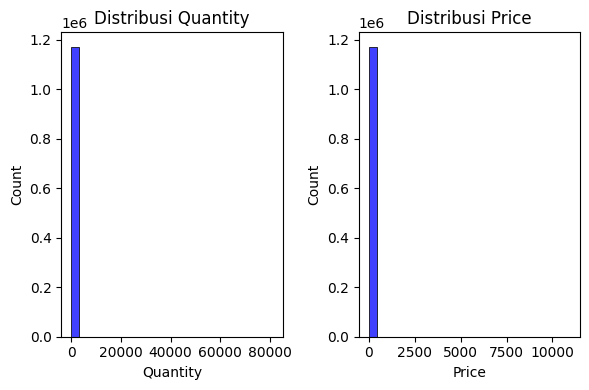

In [36]:
column_display = ['Quantity', 'Price']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column_display, 1):
  plt.subplot(1, 2, i)
  sns.histplot(df_clean[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# **Persiapan RFM**

Recency: Kapan terakhir seorang user melakukan transaksi

Frequency: Seberapa sering user melakukan transaksi

Monetary: Seberapa besar transaksi yang dilakukan user

### Pembuatan Variabel untuk RFM

In [26]:
# Hitung total belanja setiap barang
df_clean['Total'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [44]:
# Asumsi data diambil pada saat entri data terakhir
tgl_pengambilan = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Mengelompokkan data berdasarkan customer dan buat kolom baru untuk R, F, dan M
df_rfm = df_clean.groupby('CustomerID').agg(
  Recency=('InvoiceDate', lambda x: (tgl_pengambilan - x.max()).days),
  Frequency=('Invoice', 'nunique'),
  Monetary=('Total', 'sum')
).reset_index()
df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12346,326,12,154740.06
1,12347,2,8,9231.53
2,12348,75,5,3816.64
3,12349,19,4,6186.24
4,12350,310,1,668.80
...,...,...,...,...
5876,18283,4,22,4710.43
5877,18284,432,1,461.68
5878,18285,661,1,427.00
5879,18286,477,2,1296.43


In [45]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000,5881.000000
mean,15314.674205,201.457745,6.287196,4465.569318
std,1715.429759,209.474135,13.012879,21981.131016
min,12346.000000,1.000000,1.000000,0.000000
25%,13833.000000,26.000000,1.000000,467.790000
50%,15313.000000,96.000000,3.000000,1283.450000
75%,16797.000000,380.000000,7.000000,3416.480000
max,18287.000000,739.000000,398.000000,840644.340000


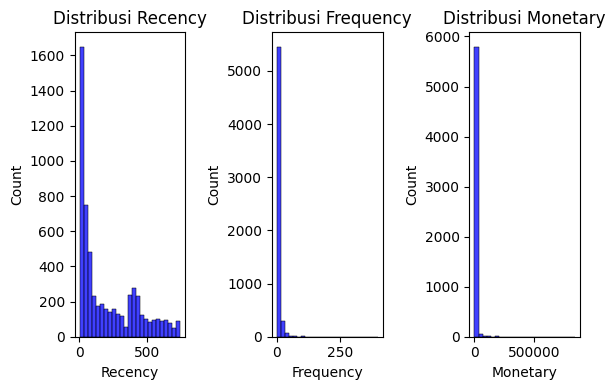

In [46]:
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

### Transformasi agar data lebih balanced

In [47]:
# Transformasi logaritmik
df_rfm_log = df_rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)
df_rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,2.564949,11.949508
1,1.098612,2.197225,9.130488
2,4.330733,1.791759,8.247388
3,2.995732,1.609438,8.730244
4,5.739793,0.693147,6.506979


In [48]:
# Standarisasi data
scaler = MinMaxScaler()
rfm_minmax = scaler.fit_transform(df_rfm_log)

df_rfm_minmax = pd.DataFrame(rfm_minmax, columns=['Recency', 'Frequency', 'Monetary'])
df_rfm_minmax.head()

,Recency,Frequency,Monetary
0,0.861894,0.353449,0.875940
1,0.068566,0.284012,0.669296
2,0.615132,0.207449,0.604562
3,0.389378,0.173022,0.639957
4,0.853411,0.000000,0.476984


In [49]:
df_rfm_minmax.describe()

,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,0.636067,0.161641,0.525984
std,0.263740,0.152856,0.106236
min,0.000000,0.000000,0.000000
25%,0.440127,0.000000,0.450827
50%,0.656390,0.130886,0.524712
75%,0.887740,0.261772,0.596445
max,1.000000,1.000000,1.000000


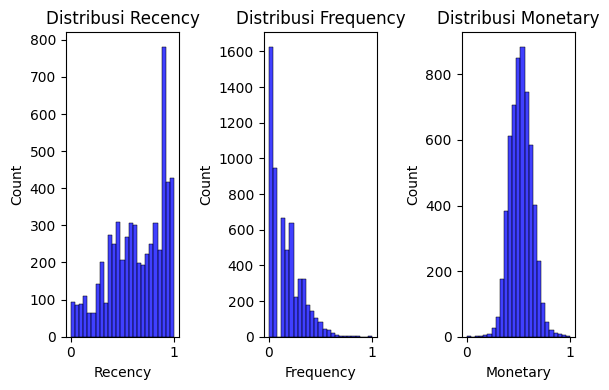

In [50]:
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm_minmax[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

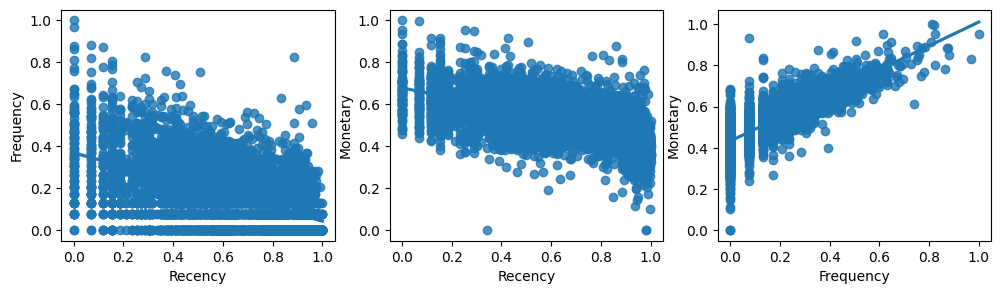

In [55]:
plt.figure(1, figsize=(12, 3))

plt.subplot(1 , 3 , 1)
sns.regplot(x='Recency' , y='Frequency' , data=df_rfm_minmax)

plt.subplot(1 , 3 , 2)
sns.regplot(x='Recency' , y='Monetary' , data=df_rfm_minmax)

plt.subplot(1 , 3 , 3)
sns.regplot(x='Frequency' , y='Monetary' , data=df_rfm_minmax)

plt.show()

# **Clustering**

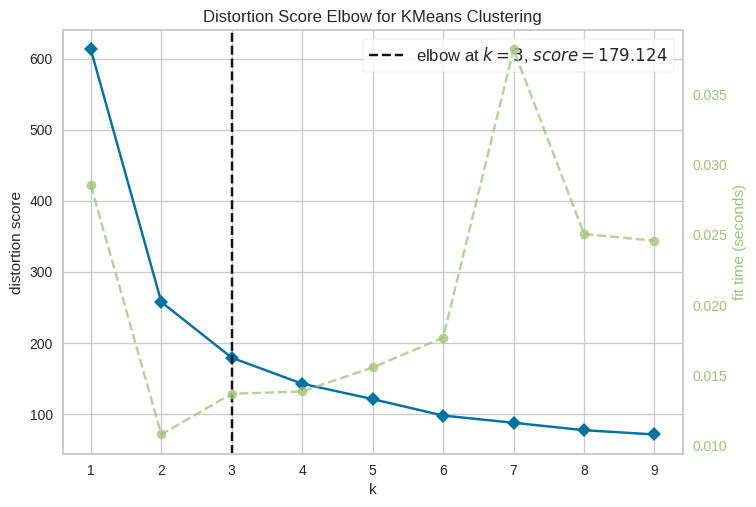

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [61]:
kmeans_elbow = KMeans()
visualizer = KElbowVisualizer(kmeans_elbow, k=(1, 10))
visualizer.fit(df_rfm_minmax)
visualizer.show()

### K-Means

In [87]:
k_elbow = 3
kmeans = KMeans(n_clusters=k_elbow)
kmeans.fit(df_rfm_minmax)

labels = kmeans.labels_

# Assign Cluster Labels
df_rfm['Cluster'] = labels
df_rfm_minmax['Cluster'] = labels

# --- 3C. Analisis Profil Cluster ---
cluster_analysis = df_rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Monetary', ascending=False)

print("\n--- Profil Rata-rata RFM Tiap Segmen ---")
print(cluster_analysis.round(2))



--- Profil Rata-rata RFM Tiap Segmen ---
         Avg_Recency  Avg_Frequency  Avg_Monetary  Count  Percentage
Cluster                                                             
1              10.72          19.13      16635.51   1002       17.04
0              76.26           5.29       3146.15   2519       42.83
2             416.08           1.90        706.82   2360       40.13


In [93]:
visual_3d = go.Scatter3d(
    x= df_rfm['Recency'],
    y= df_rfm['Frequency'],
    z= df_rfm['Monetary'],
    mode='markers',
     marker=dict(
        color = df_rfm['Cluster'],
        size= 20,
        line=dict(
            color= df_rfm['Cluster'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

### K-Means++

In [ ]:
k_elbow = 3
kmeans = KMeans(n_clusters=k_elbow, init='k-means++')
kmeans.fit(df_rfm_minmax)

labels = kmeans.labels_

# Assign Cluster Labels
df_rfm['Cluster'] = labels
df_rfm_minmax['Cluster'] = labels

# --- 3C. Analisis Profil Cluster ---
cluster_analysis = df_rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Monetary', ascending=False)

print("\n--- Profil Rata-rata RFM Tiap Segmen ---")
print(cluster_analysis.round(2))
